# M5 — order fitter + Tier-1 convergence experiment

`src/metrics.py` provides `fit_order` (sliding-window log-log fit -- keeps the
straightest, widest window, so it auto-excludes the pre-asymptotic region at
large `h` and the float64 round-off floor at tiny `h`) and `l2`.

This notebook sweeps `n_steps` for every solver in every arm on the Tier-1
Gaussian testbed, writes every run to `results/tier1_order.csv` via
`src.runlog.append_row`, fits a measured order per solver, and produces the
order table and the two headline log-log figures: error vs `h` (within-arm)
and error vs measured NFE (cross-arm, the fair cost comparison).

In [1]:
import sys, pathlib, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

p = pathlib.Path.cwd()
while not (p / "pyproject.toml").exists() and p != p.parent:
    p = p.parent
ROOT = p
sys.path.insert(0, str(ROOT))

from src.schedule import t_of_lmbda
from src.grids import grid_t, grid_lambda
from src.testbeds import GaussianTier1
from src.solvers import integrate
from src.dpm import ddim_step, march
from src.arm_c import sample_dpm_solver
from src.metrics import fit_order, l2
from src.runlog import append_row, load

RESULTS = ROOT / "results" / "tier1_order.csv"
FIGURES = ROOT / "figures"
np.set_printoptions(precision=4, suppress=True)

## 1. Sweep setup

One shared testbed (`kappa=10`, `d=3`, matching the `KAPPA`/`d` already used in
the M3/M4 tests, so these numbers are directly comparable to Gate G1's), one
shared reference trajectory (`GaussianTier1.exact`, closed form -- no
integration error in the reference itself).

`n_steps` lists are chosen **per solver**, not shared, so each fitted window
sits in that solver's asymptotic regime -- mirroring `tests/test_solvers.py`'s
own per-solver ranges rather than reusing one range for every solver. Reusing
`[8, ..., 256]` uniformly was tried first and measurably hurt two solvers:
`rk4` (pre-asymptotic contamination at `n=8`, biasing arm A's slope to 3.84 vs
the true ~3.94) and, more sharply, `ab2` on **arm B**, which has a genuine
non-monotonic bump in its error curve around `n~16-32` (error briefly *rises*
before resuming its order-2 decay -- verified reproducible, not noise; plausibly
the multistep method's spurious root interacting with arm B's curvature). Both
are fixed by starting the sweep past the point where the effect has resolved,
not by discarding data after the fact.

In [2]:
T, T_END = 1.0, 0.2
KAPPA = 10.0
SEED = 0

tb = GaussianTier1(kappa=KAPPA, d=3, seed=SEED)
xT = tb.x_T(5)
ref = tb.exact(xT, T, T_END)

# arm A/B: (theoretical order, n_steps sweep). ab2 starts later than the rest
# -- see the note above on its arm-B non-monotonic bump around n~16-32.
ARM_AB_CASES = {
    "euler":    (1, [16, 32, 64, 128, 256, 512]),
    "midpoint": (2, [16, 32, 64, 128, 256, 512]),
    "heun3":    (3, [16, 32, 64, 128, 256, 512]),
    "rk4":      (4, [16, 32, 64, 128, 256, 512]),
    "ab2":      (2, [64, 128, 256, 512, 1024, 2048]),
}

# arm C hand-written: (theoretical order, n_steps sweep). dpm1 itself is not
# swept here -- Gate G1 already proved it agrees with ddim_step to < 1e-14 and
# with the wrapper's order=1 to < 1e-10, so a separate "dpm1" curve would just
# duplicate the wrapper's below and inflate its fit window with redundant
# points. ddim is the one hand-written curve with no wrapper equivalent.
ARM_C_HAND_CASES = {
    "ddim": (1, [16, 32, 64, 128, 256, 512]),
}

# arm C wrapper (authors' code): (theoretical order, steps sweep -- steps
# must be multiples of order for singlestep_fixed to spend the full budget)
ARM_C_WRAP_CASES = {
    1: [16, 32, 64, 128, 256, 512],
    2: [16, 32, 64, 128, 256, 512],
    3: [18, 36, 72, 144, 288, 576],
}

## 2. Run the sweep, write `results/tier1_order.csv`

Fresh file each run (deleted first) so re-running this notebook doesn't
duplicate rows -- the CSV is a build artifact of this notebook, not
hand-maintained.

In [3]:
RESULTS.unlink(missing_ok=True)

def h_of(grid):
    return float(abs(grid[1] - grid[0]))

# -- arm A: rhs_t on grid_t --------------------------------------------------
for name, (order, ns) in ARM_AB_CASES.items():
    for n in ns:
        grid = grid_t(T, T_END, n)
        xf, nfe = integrate(tb.rhs_t, xT, grid, name)
        diverged = bool(np.isnan(nfe))
        err = np.nan if diverged else l2(xf, ref)
        append_row(str(RESULTS), tier=1, testbed="gaussian", arm="A", solver=name,
                    order=order, kappa=KAPPA, h=h_of(grid), nfe=nfe,
                    err_l2=err, diverged=diverged, seed=SEED)

# -- arm B: rhs_lambda on grid_lambda ----------------------------------------
for name, (order, ns) in ARM_AB_CASES.items():
    for n in ns:
        grid = grid_lambda(T, T_END, n)
        xf, nfe = integrate(tb.rhs_lambda, xT, grid, name)
        diverged = bool(np.isnan(nfe))
        err = np.nan if diverged else l2(xf, ref)
        append_row(str(RESULTS), tier=1, testbed="gaussian", arm="B", solver=name,
                    order=order, kappa=KAPPA, h=h_of(grid), nfe=nfe,
                    err_l2=err, diverged=diverged, seed=SEED)

# -- arm C, hand-written: ddim_step on a lambda-uniform grid ----------------
def t_grid_for(T, t_end, n):
    tg = t_of_lmbda(grid_lambda(T, t_end, n))
    tg[0], tg[-1] = T, t_end
    return tg

STEP_FN = {"ddim": ddim_step}
for name, (order, ns) in ARM_C_HAND_CASES.items():
    for n in ns:
        tg = t_grid_for(T, T_END, n)
        xf = march(STEP_FN[name], tb.eps, xT, tg)
        nfe = n  # one eps call per step, both are one-step arm-C methods
        h = h_of(grid_lambda(T, T_END, n))
        append_row(str(RESULTS), tier=1, testbed="gaussian", arm="C", solver=name,
                    order=order, kappa=KAPPA, h=h, nfe=nfe,
                    err_l2=l2(xf, ref), diverged=False, seed=SEED)

# -- arm C, authors' code: dpm1/dpm2/dpm3, singlestep_fixed -----------------
for order, steps_list in ARM_C_WRAP_CASES.items():
    for steps in steps_list:
        xf, nfe = sample_dpm_solver(tb.eps, xT, T, T_END, order=order, steps=steps)
        assert nfe == (steps // order) * order
        h = h_of(grid_lambda(T, T_END, steps // order))
        append_row(str(RESULTS), tier=1, testbed="gaussian", arm="C", solver=f"dpm{order}",
                    order=order, kappa=KAPPA, h=h, nfe=nfe,
                    err_l2=l2(xf, ref), diverged=False, seed=SEED)

df = load(str(RESULTS))
print(f"{len(df)} rows written to {RESULTS.relative_to(ROOT)}")
df.head()

84 rows written to results/tier1_order.csv


,tier,testbed,arm,solver,order,kappa,h,nfe,err_l2,diverged,seed
0,1,gaussian,A,euler,1,10.0,0.050000,16,0.114982,0,0
1,1,gaussian,A,euler,1,10.0,0.025000,32,0.056223,0,0
2,1,gaussian,A,euler,1,10.0,0.012500,64,0.027794,0,0
3,1,gaussian,A,euler,1,10.0,0.006250,128,0.013818,0,0
4,1,gaussian,A,euler,1,10.0,0.003125,256,0.006889,0,0


## 2b. The ab2 / arm-B bump, shown directly

The claim above (a real, reproducible non-monotonic bump, not noise) is
checked here with a much finer sweep over `n`, on the same testbed. The
headline sweep above starts at `n=64`, past where this resolves.

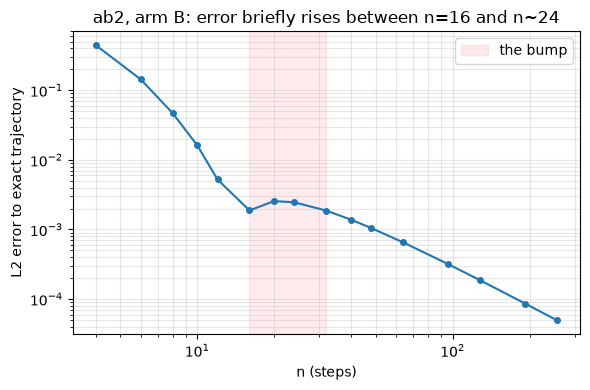

n, err:
     4  4.454679e-01
     6  1.435664e-01
     8  4.705019e-02
    10  1.614235e-02
    12  5.226639e-03
    16  1.874332e-03
    20  2.559048e-03
    24  2.453306e-03
    32  1.865000e-03
    40  1.382490e-03
    48  1.048199e-03
    64  6.519543e-04
    96  3.176010e-04
   128  1.864979e-04
   192  8.637677e-05
   256  4.956783e-05


In [4]:
ns_fine = [4, 6, 8, 10, 12, 16, 20, 24, 32, 40, 48, 64, 96, 128, 192, 256]
errs_fine = []
for n in ns_fine:
    grid = grid_lambda(T, T_END, n)
    xf, nfe = integrate(tb.rhs_lambda, xT, grid, "ab2")
    errs_fine.append(l2(xf, ref))

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(ns_fine, errs_fine, "-o", ms=4)
ax.axvspan(16, 32, color="red", alpha=0.08, label="the bump")
ax.set_xlabel("n (steps)")
ax.set_ylabel("L2 error to exact trajectory")
ax.set_title("ab2, arm B: error briefly rises between n=16 and n~24")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

print("n, err:")
for n, e in zip(ns_fine, errs_fine):
    print(f"  {n:>4d}  {e:.6e}")

## 3. Order table

`fit_order` per `(arm, solver)` group, sorted by `h` descending (matching the
sweep order). Report theoretical order alongside the measured slope, the fit
window (in `h`), R², and how many of the swept points the window kept.

In [5]:
rows = []
for (arm, solver), g in df.groupby(["arm", "solver"]):
    g = g.sort_values("h", ascending=False)
    fit = fit_order(g["h"].to_numpy(), g["err_l2"].to_numpy())
    rows.append(dict(
        arm=arm, solver=solver, theoretical_order=int(g["order"].iloc[0]),
        measured_slope=fit["slope"], r2=fit["r2"], window=fit["window"],
        n_in_window=fit["n"], n_swept=len(g),
    ))

order_table = pd.DataFrame(rows).sort_values(["arm", "solver"]).reset_index(drop=True)
pd.set_option("display.width", 120)
order_table

,arm,solver,theoretical_order,measured_slope,r2,window,n_in_window,n_swept
0,A,ab2,2,2.032912,0.999951,"(0.0124999999999999, 0.0003906249999999)",6,6
1,A,euler,1,1.011685,0.999971,"(0.05, 0.0015625)",6,6
2,A,heun3,3,3.013817,0.999994,"(0.05, 0.0015625)",6,6
3,A,midpoint,2,2.028091,0.999972,"(0.05, 0.0015625)",6,6
4,A,rk4,4,3.937931,0.999917,"(0.05, 0.0015625)",6,6
5,B,ab2,2,1.935034,0.999715,"(0.0836403208122806, 0.0026137600253841)",6,6
6,B,euler,1,1.022837,0.999883,"(0.3345612832491236, 0.0104550401015348)",6,6
7,B,heun3,3,3.014620,0.999977,"(0.3345612832491236, 0.0104550401015348)",6,6
8,B,midpoint,2,2.056904,0.999838,"(0.3345612832491236, 0.0104550401015348)",6,6
9,B,rk4,4,3.921166,0.999898,"(0.3345612832491236, 0.0104550401015348)",6,6


## 4. Figures

**Error vs h** (within-arm; different arms use different time variables, so
comparing slopes across arms here is valid but comparing absolute cost is
not). **Error vs NFE** (cross-arm, the fair cost comparison -- guide's
headline plot).

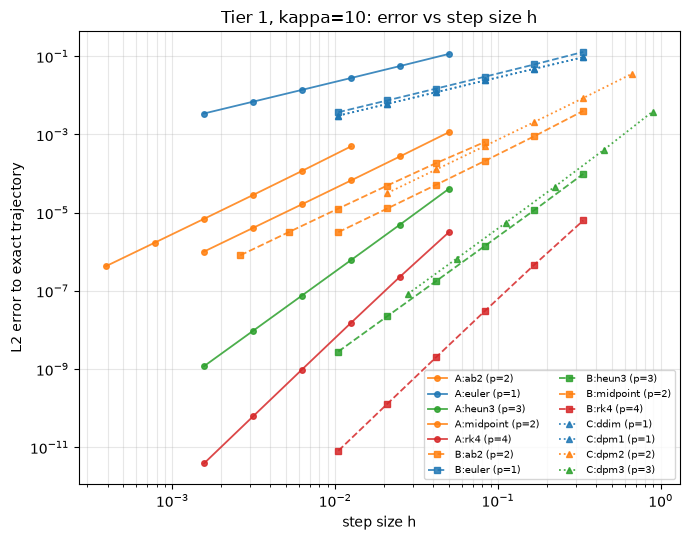

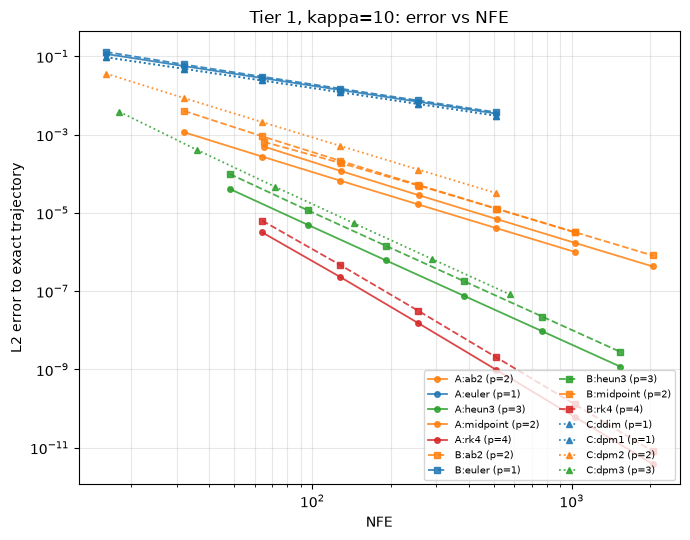

In [6]:
ORDER_COLOR = {1: "tab:blue", 2: "tab:orange", 3: "tab:green", 4: "tab:red"}
ARM_STYLE = {"A": "-o", "B": "--s", "C": ":^"}

def plot_err_vs(df, xcol, xlabel, fname):
    fig, ax = plt.subplots(figsize=(7, 5.5))
    for (arm, solver), g in df.groupby(["arm", "solver"]):
        g = g.sort_values(xcol)
        order = int(g["order"].iloc[0])
        ax.loglog(g[xcol], g["err_l2"], ARM_STYLE[arm],
                   color=ORDER_COLOR[order], alpha=0.85, ms=4, lw=1.3,
                   label=f"{arm}:{solver} (p={order})")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("L2 error to exact trajectory")
    ax.set_title(f"Tier 1, kappa={KAPPA:g}: error vs {xlabel}")
    ax.legend(fontsize=7, ncol=2, loc="lower right")
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURES / fname, dpi=150)
    plt.show()

plot_err_vs(df, "h", "step size h", "05_error_vs_h.png")
plot_err_vs(df, "nfe", "NFE", "05_error_vs_nfe.png")

## 5. Validation — run the unit tests

In [7]:
out = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_metrics.py", "-q"],
    cwd=ROOT, capture_output=True, text=True,
)
print(out.stdout); print(out.stderr)
assert out.returncode == 0, "M5 metrics tests failed"
print("M5 validation: PASS")

.....                                                                    [100%]


M5 validation: PASS
